In [4]:
from pathlib import Path
from collections import Counter
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
# Cari folder project
ROOT = Path.cwd()

if not (ROOT / "dataset_merged").exists():
    ROOT = ROOT.parent

DATASET = ROOT / "dataset_merged"

print("Project :", ROOT)
print("Dataset :", DATASET)

Project : c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System
Dataset : c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_merged


In [6]:
# Baca data.yaml
DATA_YAML = DATASET / "data.yaml"

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

print("Jumlah kelas :", len(class_names))
print("Daftar kelas :", class_names)

Jumlah kelas : 3
Daftar kelas : ['space-empty', 'space-occupied', 'illegal-parking']


In [7]:
splits = ["train", "valid", "test"]

image_counts = {}

for split in splits:
    image_dir = DATASET / split / "images"
    
    images = list(image_dir.glob("*"))
    images = [x for x in images if x.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]
    
    image_counts[split] = len(images)

print("Jumlah gambar:")
for split, count in image_counts.items():
    print(f"{split:5s}: {count}")
    
print("Total:", sum(image_counts.values()))

Jumlah gambar:
train: 9688
valid: 2198
test : 761
Total: 12647


In [9]:
total_images = sum(image_counts.values())

print("Rasio dataset:")
for split, count in image_counts.items():
    ratio = count / total_images * 100
    print(f"{split:5s}: {count} gambar ({ratio:.2f}%)")

Rasio dataset:
train: 9688 gambar (76.60%)
valid: 2198 gambar (17.38%)
test : 761 gambar (6.02%)


In [11]:
class_counts = Counter()

for split in splits:
    label_dir = DATASET / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                line = line.strip()
                
                if line:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

print("Jumlah objek per kelas:")

for class_id, count in sorted(class_counts.items()):
    print(f"{class_id} - {class_names[class_id]} : {count}")

Jumlah objek per kelas:
0 - space-empty : 301745
1 - space-occupied : 271567
2 - illegal-parking : 1231


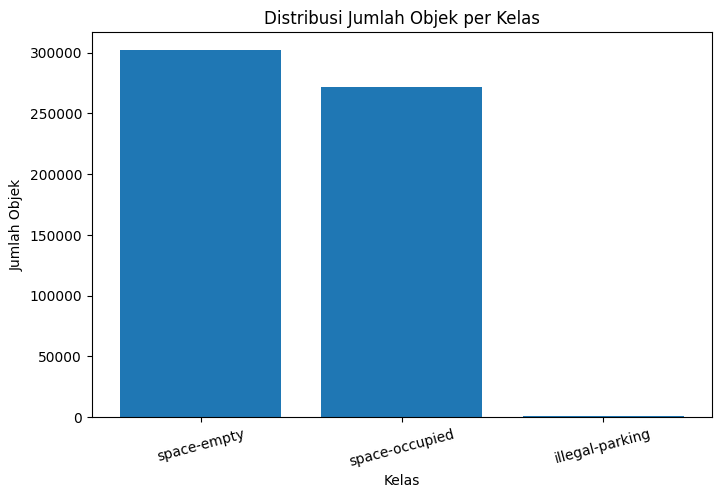

In [12]:
labels = [class_names[i] for i in sorted(class_counts.keys())]
values = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Distribusi Jumlah Objek per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Objek")
plt.xticks(rotation=15)

plt.show()

In [13]:
format_counts = Counter()

for split in splits:
    image_dir = DATASET / split / "images"
    
    for image_file in image_dir.iterdir():
        if image_file.is_file():
            format_counts[image_file.suffix.lower()] += 1

print("Format gambar:")

for ext, count in format_counts.items():
    print(f"{ext}: {count}")

Format gambar:
.jpg: 12647


In [14]:
resolution_data = []

for split in splits:
    image_dir = DATASET / split / "images"
    
    for image_file in image_dir.iterdir():
        if image_file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            try:
                with Image.open(image_file) as img:
                    width, height = img.size
                    
                    resolution_data.append({
                        "split": split,
                        "file": image_file.name,
                        "width": width,
                        "height": height,
                        "resolution": f"{width}x{height}"
                    })
                    
            except Exception:
                pass

resolution_df = pd.DataFrame(resolution_data)

resolution_df.head()

,split,file,width,height,resolution
0,train,train_00001.jpg,640,640,640x640
1,train,train_00002.jpg,640,640,640x640
2,train,train_00003.jpg,640,640,640x640
3,train,train_00004.jpg,640,640,640x640
4,train,train_00005.jpg,640,640,640x640


In [15]:
print("Statistik resolusi:")

print("Lebar minimum :", resolution_df["width"].min())
print("Lebar maksimum:", resolution_df["width"].max())

print("Tinggi minimum :", resolution_df["height"].min())
print("Tinggi maksimum:", resolution_df["height"].max())

Statistik resolusi:
Lebar minimum : 180
Lebar maksimum: 640
Tinggi minimum : 180
Tinggi maksimum: 640


In [16]:
resolution_summary = (
    resolution_df["resolution"]
    .value_counts()
    .head(10)
)

print(resolution_summary)

resolution
180x180    9968
640x640    2372
512x512     307
Name: count, dtype: int64


In [17]:
corrupt_images = []
low_resolution_images = []
zero_size_images = []

# Batas resolusi rendah
MIN_WIDTH = 180
MIN_HEIGHT = 180

for split in splits:
    image_dir = DATASET / split / "images"
    
    for image_file in image_dir.iterdir():
        
        if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            continue
        
        # Cek ukuran file
        if image_file.stat().st_size == 0:
            zero_size_images.append(image_file)
            continue
        
        # Cek gambar dapat dibuka
        try:
            with Image.open(image_file) as img:
                width, height = img.size
                
                # Cek resolusi rendah
                if width < MIN_WIDTH or height < MIN_HEIGHT:
                    low_resolution_images.append(image_file)
                    
        except Exception:
            corrupt_images.append(image_file)

print("File korup          :", len(corrupt_images))
print("Resolusi rendah     :", len(low_resolution_images))
print("File ukuran 0 byte  :", len(zero_size_images))

File korup          : 0
Resolusi rendah     : 0
File ukuran 0 byte  : 0


In [18]:
import hashlib

hashes = {}
duplicate_images = []

for split in splits:
    image_dir = DATASET / split / "images"
    
    for image_file in image_dir.iterdir():
        
        if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            continue
        
        try:
            file_hash = hashlib.md5(image_file.read_bytes()).hexdigest()
            
            if file_hash in hashes:
                duplicate_images.append({
                    "duplicate": str(image_file),
                    "original": hashes[file_hash]
                })
            else:
                hashes[file_hash] = str(image_file)
                
        except Exception:
            pass

print("Jumlah gambar duplikat:", len(duplicate_images))

Jumlah gambar duplikat: 19


In [19]:
# Distribusi kelas pada setiap split
split_class_counts = {}

for split in splits:
    
    counts = Counter()
    label_dir = DATASET / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    counts[class_id] += 1
    
    split_class_counts[split] = counts


# Buat tabel distribusi kelas
class_ids = range(len(class_names))

bias_df = pd.DataFrame(
    {
        split: [
            split_class_counts[split].get(class_id, 0)
            for class_id in class_ids
        ]
        for split in splits
    },
    index=class_names
)

bias_df

,train,valid,test
space-empty,224060,59585,18100
space-occupied,203883,51305,16379
illegal-parking,1057,120,54


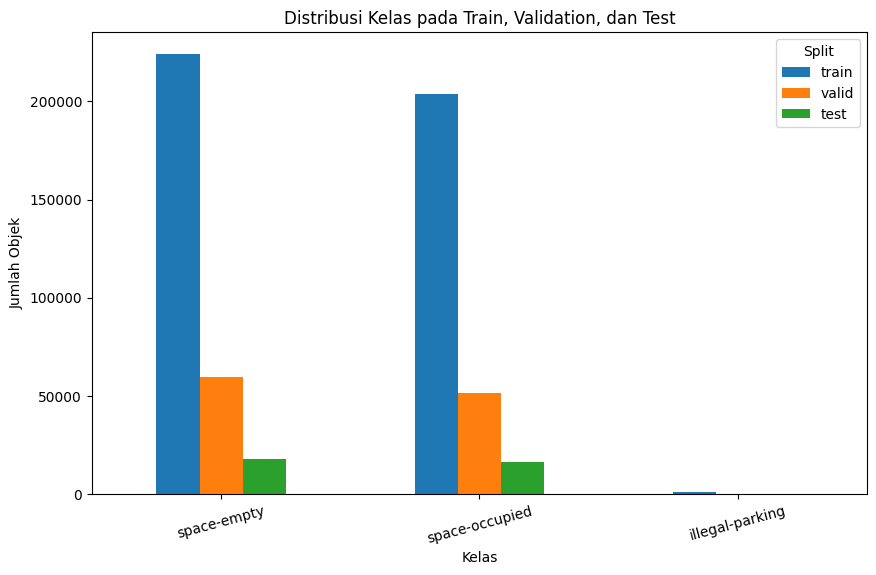

In [20]:
# Visualisasi distribusi kelas per split

bias_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribusi Kelas pada Train, Validation, dan Test")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Objek")
plt.xticks(rotation=15)
plt.legend(title="Split")

plt.show()

In [21]:
print("=== RINGKASAN EDA DATASET ===")

# Jumlah dan nama kelas
print("Jumlah kelas :", len(class_names))
print("Daftar kelas :", class_names)

# Jumlah gambar
print("\nJumlah gambar sebelum cleaning:")
for split in splits:
    print(f"- {split} : {image_counts[split]} gambar")

print(f"- Total  : {total_images} gambar")

# Rasio dataset
print("\nRasio dataset:")
for split in splits:
    ratio = image_counts[split] / total_images * 100
    print(f"- {split} : {ratio:.2f}%")

# Distribusi kelas
print("\nJumlah objek per kelas:")
for class_id in sorted(class_counts.keys()):
    print(f"- {class_names[class_id]} : {class_counts[class_id]}")

# Kualitas gambar
print("\nKualitas gambar:")
print("- File korup      :", len(corrupt_images))
print("- Duplikat        :", len(duplicate_images))
print("- Resolusi rendah :", len(low_resolution_images))

# Resolusi
print("\nResolusi gambar:")
print("- Lebar minimum  :", resolution_df["width"].min())
print("- Lebar maksimum :", resolution_df["width"].max())
print("- Tinggi minimum :", resolution_df["height"].min())
print("- Tinggi maksimum:", resolution_df["height"].max())

print("\n=== EDA SELESAI ===")

=== RINGKASAN EDA DATASET ===
Jumlah kelas : 3
Daftar kelas : ['space-empty', 'space-occupied', 'illegal-parking']

Jumlah gambar sebelum cleaning:
- train : 9688 gambar
- valid : 2198 gambar
- test : 761 gambar
- Total  : 12647 gambar

Rasio dataset:
- train : 76.60%
- valid : 17.38%
- test : 6.02%

Jumlah objek per kelas:
- space-empty : 301745
- space-occupied : 271567
- illegal-parking : 1231

Kualitas gambar:
- File korup      : 0
- Duplikat        : 19
- Resolusi rendah : 0

Resolusi gambar:
- Lebar minimum  : 180
- Lebar maksimum : 640
- Tinggi minimum : 180
- Tinggi maksimum: 640

=== EDA SELESAI ===
